# C-MAPSS FD001 RUL Baseline

This notebook builds the first predictive-maintenance baseline after data
extraction:

1. Load and validate FD001.
2. Create piecewise-linear RUL labels.
3. Engineer leakage-safe rolling features per engine.
4. Split training engines into train and validation groups.
5. Compare a naive baseline with XGBoost.
6. Optionally tune hyperparameters using validation engines only.
7. Evaluate once on the official FD001 test set.
8. Save the model, feature contract, metrics, predictions, and plots.

The official test set is never used for model selection.

In [1]:

## %pip install -U numpy pandas scikit-learn xgboost matplotlib seaborn joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 104.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 178.2 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.4
    Uninstalling numpy-2.3.4:
      Successfully uninstalled numpy-2.3.4━━━━━━ 0/2 [numpy]
  Attempting uninstall: pandas━━━━━━━━━━━━━━━━━━ 0/2 [numpy]
    Found existing installation: pandas 2.3.3 0/2 [numpy]
    Uninstalling pandas-2.3.3:━━━━━━━━━━━━━━ 0/2 [numpy]
      Successfully uninstalled pandas-2.3.3━━━━━━━━━━━━━━━━━━━ 1/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2025.10.7 requires cut_cross_entropy, which is not installed.
unsloth-zoo 2025.10.7 requires torchao!=0.14.0,>=0.13.0, which is not installed.
numba 0.61.2 requires numpy

In [2]:
from pathlib import Path
import json
import random
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit, ParameterGrid
from xgboost import XGBRegressor

SEED = 42
RUL_CAP = 125
ROLLING_WINDOWS = (5, 10, 20)
RUN_TUNING = False

random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

ARTIFACT_DIR = Path("artifacts/cmapss/fd001")
FIGURE_DIR = ARTIFACT_DIR / "figures"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Working directory:", Path.cwd().resolve())
print("Artifacts:", ARTIFACT_DIR.resolve())


Working directory: /workspace/notebooks
Artifacts: /workspace/notebooks/artifacts/cmapss/fd001


## 2. Locate and Load FD001

The path resolver supports both repository layouts:

- `data/CMAPSSData/train_FD001.txt`
- `data/train_FD001.txt`


In [3]:
COLUMNS = (
    ["unit", "cycle"]
    + [f"op_setting_{index}" for index in range(1, 4)]
    + [f"sensor_{index}" for index in range(1, 22)]
)

DATA_CANDIDATES = (
    Path("data/CMAPSSData"),
    Path("data"),
    Path("../data/CMAPSSData"),
    Path("../data"),
    Path("CMAPSSData"),
)


def resolve_data_dir() -> Path:
    required = ("train_FD001.txt", "test_FD001.txt", "RUL_FD001.txt")
    for candidate in DATA_CANDIDATES:
        if all((candidate / filename).is_file() for filename in required):
            return candidate
    searched = "\n".join(str(path.resolve()) for path in DATA_CANDIDATES)
    raise FileNotFoundError(f"FD001 files not found. Searched:\n{searched}")


DATA_DIR = resolve_data_dir()
print("Using data directory:", DATA_DIR.resolve())

train_raw = pd.read_csv(
    DATA_DIR / "train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=COLUMNS,
)
test_raw = pd.read_csv(
    DATA_DIR / "test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=COLUMNS,
)
test_rul_raw = pd.read_csv(
    DATA_DIR / "RUL_FD001.txt",
    sep=r"\s+",
    header=None,
    names=["RUL"],
)

assert train_raw.shape[1] == 26
assert test_raw.shape[1] == 26
assert test_raw["unit"].nunique() == len(test_rul_raw)
assert train_raw.isna().sum().sum() == 0
assert test_raw.isna().sum().sum() == 0

print("Train:", train_raw.shape, "| engines:", train_raw["unit"].nunique())
print("Test:", test_raw.shape, "| engines:", test_raw["unit"].nunique())
print("Official test labels:", len(test_rul_raw))
display(train_raw.head())


Using data directory: /workspace/notebooks/data/CMAPSSData
Train: (20631, 26) | engines: 100
Test: (13096, 26) | engines: 100
Official test labels: 100


,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 3. Create RUL Targets

For each training engine:

```text
raw RUL = final observed cycle - current cycle
target RUL = min(raw RUL, 125)
```

The cap prevents very early healthy cycles from dominating regression and is a
standard C-MAPSS baseline choice.


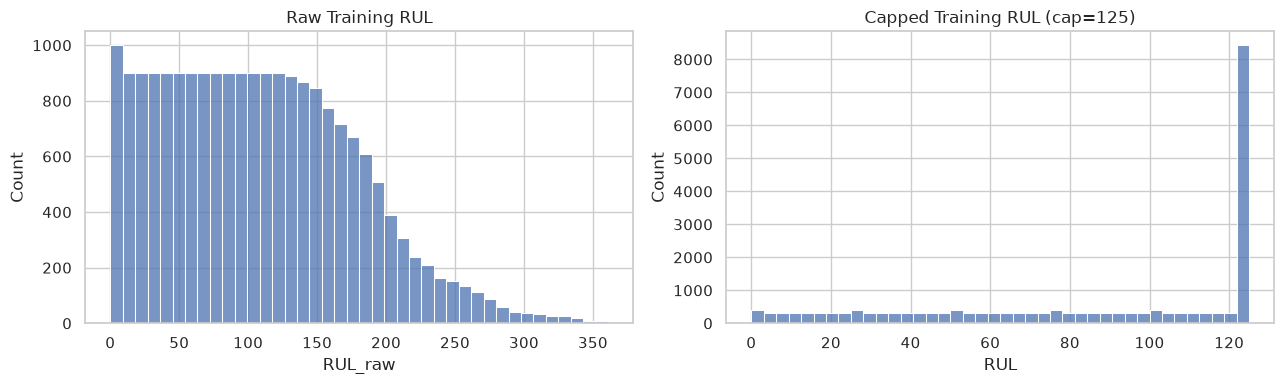

In [4]:
train_labeled = train_raw.copy()
max_cycle = train_labeled.groupby("unit")["cycle"].transform("max")
train_labeled["RUL_raw"] = max_cycle - train_labeled["cycle"]
train_labeled["RUL"] = train_labeled["RUL_raw"].clip(upper=RUL_CAP)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(train_labeled["RUL_raw"], bins=40, ax=axes[0])
axes[0].set_title("Raw Training RUL")
sns.histplot(train_labeled["RUL"], bins=40, ax=axes[1])
axes[1].set_title(f"Capped Training RUL (cap={RUL_CAP})")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "rul_target_distribution.png", dpi=150)
plt.show()


## 4. Select Sensors and Engineer Features

Constant and near-constant columns are learned from the training set only.
Rolling statistics and deltas are calculated independently within each engine,
so no information crosses engine boundaries.


In [5]:
BASE_CANDIDATES = [
    column
    for column in COLUMNS
    if column not in ("unit",)
]

feature_std = train_raw[BASE_CANDIDATES].std()
CONSTANT_COLUMNS = feature_std[feature_std <= 1e-8].index.tolist()
BASE_FEATURES = [
    column for column in BASE_CANDIDATES if column not in CONSTANT_COLUMNS
]
SENSOR_FEATURES = [
    column for column in BASE_FEATURES if column.startswith("sensor_")
]

print("Dropped constant columns:", CONSTANT_COLUMNS)
print("Base features:", BASE_FEATURES)


Dropped constant columns: ['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Base features: ['cycle', 'op_setting_1', 'op_setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [6]:
def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.sort_values(["unit", "cycle"]).copy()
    grouped = result.groupby("unit", sort=False)
    derived = {}

    for sensor in SENSOR_FEATURES:
        derived[f"{sensor}_delta"] = grouped[sensor].diff().fillna(0.0)

    for window in ROLLING_WINDOWS:
        for sensor in SENSOR_FEATURES:
            rolling = grouped[sensor].rolling(window=window, min_periods=1)
            derived[f"{sensor}_mean_{window}"] = (
                rolling.mean().reset_index(level=0, drop=True)
            )
            derived[f"{sensor}_std_{window}"] = (
                rolling.std().reset_index(level=0, drop=True).fillna(0.0)
            )

    derived_frame = pd.DataFrame(derived, index=result.index)
    return pd.concat([result, derived_frame], axis=1)


train_features = engineer_features(train_labeled)
test_features = engineer_features(test_raw)

TARGET_COLUMNS = {"RUL", "RUL_raw"}
FEATURE_COLUMNS = [
    column
    for column in train_features.columns
    if column not in TARGET_COLUMNS and column != "unit"
]

assert set(FEATURE_COLUMNS).issubset(test_features.columns)
assert not train_features[FEATURE_COLUMNS].isna().any().any()
assert not test_features[FEATURE_COLUMNS].isna().any().any()

print("Engineered feature count:", len(FEATURE_COLUMNS))
print("Train matrix shape:", train_features[FEATURE_COLUMNS].shape)


Engineered feature count: 130
Train matrix shape: (20631, 130)


## 5. Leakage-Safe Engine Split

Rows from one engine must never appear in both training and validation. The
split therefore operates on `unit` groups rather than random telemetry rows.


In [8]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED,
)
train_indices, validation_indices = next(
    splitter.split(
        train_features,
        groups=train_features["unit"],
    )
)

development_train = train_features.iloc[train_indices].copy()
validation = train_features.iloc[validation_indices].copy()

X_train = development_train[FEATURE_COLUMNS]
y_train = development_train["RUL"]
X_validation = validation[FEATURE_COLUMNS]
y_validation = validation["RUL"]

train_units = set(development_train["unit"])
validation_units = set(validation["unit"])
assert train_units.isdisjoint(validation_units)

print("Training engines:", len(train_units))
print("Validation engines:", len(validation_units))
print("Training rows:", len(X_train))
print("Validation rows:", len(X_validation))


Training engines: 80
Validation engines: 20
Training rows: 16561
Validation rows: 4070


## 6. Metrics and Naive Baseline

RMSE is the primary regression metric. MAE and R-squared provide additional
context. The asymmetric NASA score penalizes late predictions more heavily.


In [9]:
def nasa_score(y_true, y_pred) -> float:
    errors = np.asarray(y_pred) - np.asarray(y_true)
    penalties = np.where(
        errors < 0,
        np.exp(-errors / 13.0) - 1.0,
        np.exp(errors / 10.0) - 1.0,
    )
    return float(np.sum(penalties))


def regression_metrics(y_true, y_pred) -> dict:
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
        "NASA_score": nasa_score(y_true, y_pred),
    }


dummy = DummyRegressor(strategy="median")
dummy.fit(X_train, y_train)
dummy_validation_predictions = dummy.predict(X_validation)
dummy_metrics = regression_metrics(y_validation, dummy_validation_predictions)

display(pd.DataFrame([{"model": "Median baseline", **dummy_metrics}]))


,model,RMSE,MAE,R2,NASA_score
0,Median baseline,44.933421,35.941032,-0.160221,6.254161e+06


## 7. Train XGBoost Baseline

Start with one fixed configuration. Only enable tuning after this baseline runs
successfully and its validation result is recorded.


In [10]:
BASELINE_PARAMS = {
    "objective": "reg:squarederror",
    "n_estimators": 500,
    "learning_rate": 0.05,
    "max_depth": 6,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "random_state": SEED,
    "n_jobs": -1,
    "tree_method": "hist",
}

start_time = time.perf_counter()
baseline_model = XGBRegressor(**BASELINE_PARAMS)
baseline_model.fit(X_train, y_train)
baseline_seconds = time.perf_counter() - start_time

baseline_validation_predictions = baseline_model.predict(X_validation)
baseline_metrics = regression_metrics(
    y_validation,
    baseline_validation_predictions,
)

validation_comparison = pd.DataFrame(
    [
        {"model": "Median baseline", **dummy_metrics},
        {"model": "XGBoost baseline", **baseline_metrics},
    ]
)
display(validation_comparison)
print(f"Baseline training time: {baseline_seconds:.2f} seconds")



,model,RMSE,MAE,R2,NASA_score
0,Median baseline,44.933421,35.941032,-0.160221,6.254161e+06
1,XGBoost baseline,14.599424,9.886780,0.877518,1.797786e+04


Baseline training time: 1.81 seconds


## 8. Optional Hyperparameter Tuning

`RUN_TUNING` is `False` by default. When enabled, candidates are compared only
on the validation-engine split. The official test set remains untouched.


In [11]:
TUNING_GRID = {
    "max_depth": [4, 6, 8],
    "min_child_weight": [1, 5, 10],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

best_model = baseline_model
best_params = BASELINE_PARAMS.copy()
best_validation_metrics = baseline_metrics
tuning_results = []

if RUN_TUNING:
    for candidate in ParameterGrid(TUNING_GRID):
        params = {
            **BASELINE_PARAMS,
            **candidate,
            "n_estimators": 600,
        }
        model = XGBRegressor(**params)
        model.fit(X_train, y_train)
        predictions = model.predict(X_validation)
        metrics = regression_metrics(y_validation, predictions)
        tuning_results.append({**candidate, **metrics})

        if metrics["RMSE"] < best_validation_metrics["RMSE"]:
            best_model = model
            best_params = params
            best_validation_metrics = metrics

    tuning_results = pd.DataFrame(tuning_results).sort_values("RMSE")
    display(tuning_results.head(10))
else:
    print("Tuning skipped. Set RUN_TUNING = True and rerun from this cell if needed.")

print("Selected validation metrics:", best_validation_metrics)
print("Selected parameters:", best_params)


Tuning skipped. Set RUN_TUNING = True and rerun from this cell if needed.
Selected validation metrics: {'RMSE': 14.599424251543706, 'MAE': 9.88677978515625, 'R2': 0.8775177597999573, 'NASA_score': 17977.86283605573}
Selected parameters: {'objective': 'reg:squarederror', 'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist'}


## 9. Validation Diagnostics

These plots show global fit, residual behavior, and trajectories for held-out
engines.


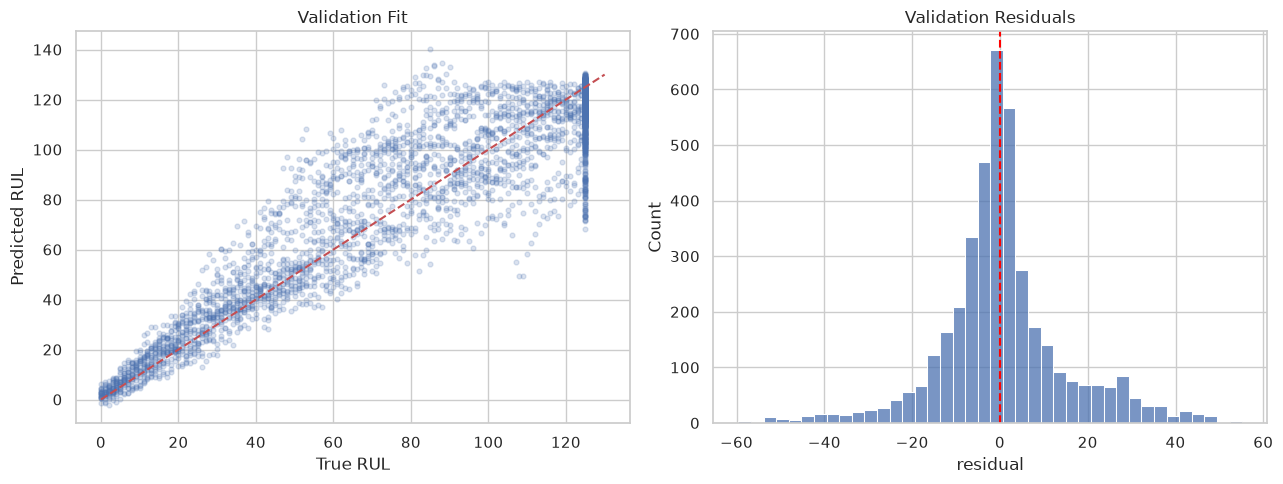

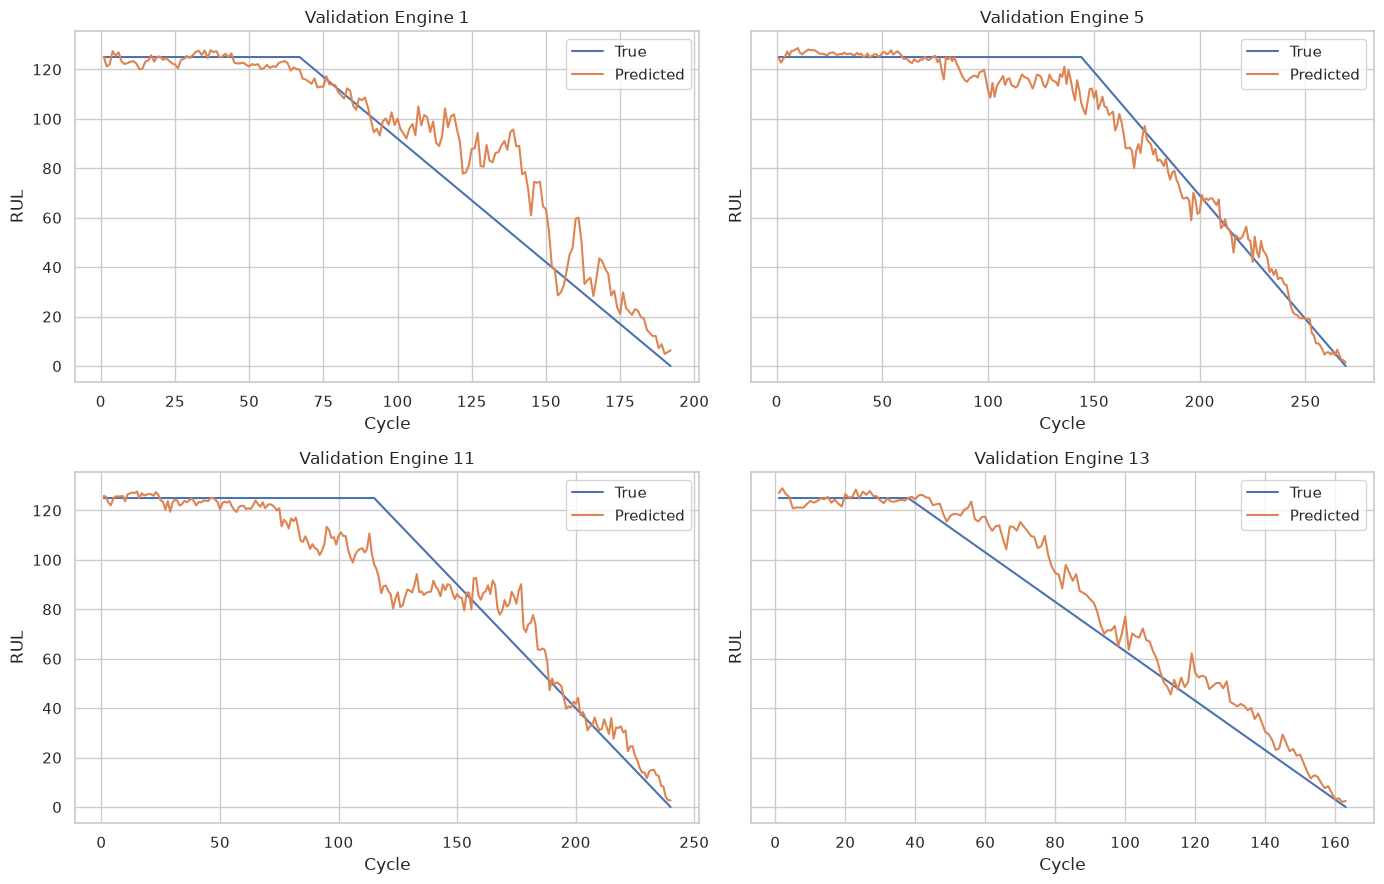

In [12]:
selected_validation_predictions = best_model.predict(X_validation)
validation_plot = validation[["unit", "cycle", "RUL"]].copy()
validation_plot["predicted_RUL"] = selected_validation_predictions
validation_plot["residual"] = (
    validation_plot["predicted_RUL"] - validation_plot["RUL"]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(
    validation_plot["RUL"],
    validation_plot["predicted_RUL"],
    alpha=0.2,
    s=12,
)
limit = RUL_CAP + 5
axes[0].plot([0, limit], [0, limit], "r--")
axes[0].set(xlabel="True RUL", ylabel="Predicted RUL", title="Validation Fit")

sns.histplot(validation_plot["residual"], bins=40, ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Validation Residuals")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "validation_diagnostics.png", dpi=150)
plt.show()

sample_units = sorted(validation_units)[:4]
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
for axis, unit in zip(axes.flat, sample_units):
    engine = validation_plot[validation_plot["unit"] == unit]
    axis.plot(engine["cycle"], engine["RUL"], label="True")
    axis.plot(engine["cycle"], engine["predicted_RUL"], label="Predicted")
    axis.set_title(f"Validation Engine {unit}")
    axis.set_xlabel("Cycle")
    axis.set_ylabel("RUL")
    axis.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "validation_engine_trajectories.png", dpi=150)
plt.show()


## 10. Retrain on All Training Engines

After selecting parameters with validation data, train one final model on all
FD001 training engines.


In [13]:
X_full_train = train_features[FEATURE_COLUMNS]
y_full_train = train_features["RUL"]

final_model = XGBRegressor(**best_params)
final_model.fit(X_full_train, y_full_train)

print("Final model trained on rows:", len(X_full_train))
print("Final model trained on engines:", train_features["unit"].nunique())


Final model trained on rows: 20631
Final model trained on engines: 100


In [14]:
test_last_rows = (
    test_features.sort_values(["unit", "cycle"])
    .groupby("unit", as_index=False)
    .tail(1)
    .sort_values("unit")
    .reset_index(drop=True)
)

official_test_rul = test_rul_raw["RUL"].to_numpy()
official_test_rul_capped = np.minimum(official_test_rul, RUL_CAP)
test_predictions = np.clip(
    final_model.predict(test_last_rows[FEATURE_COLUMNS]),
    0,
    RUL_CAP,
)

assert len(test_predictions) == len(official_test_rul)

test_metrics_capped = regression_metrics(
    official_test_rul_capped,
    test_predictions,
)
test_metrics_uncapped = regression_metrics(
    official_test_rul,
    test_predictions,
)

test_predictions_frame = pd.DataFrame(
    {
        "unit": test_last_rows["unit"].to_numpy(),
        "last_cycle": test_last_rows["cycle"].to_numpy(),
        "true_RUL": official_test_rul,
        "true_RUL_capped": official_test_rul_capped,
        "predicted_RUL": test_predictions,
    }
)
test_predictions_frame["absolute_error"] = np.abs(
    test_predictions_frame["predicted_RUL"]
    - test_predictions_frame["true_RUL_capped"]
)

display(
    pd.DataFrame(
        [
            {"evaluation": "Official test, capped", **test_metrics_capped},
            {"evaluation": "Official test, uncapped", **test_metrics_uncapped},
        ]
    )
)
display(test_predictions_frame.head(10))


,evaluation,RMSE,MAE,R2,NASA_score
0,"Official test, capped",16.045179,11.352059,0.839683,482.996561
1,"Official test, uncapped",17.267247,12.422059,0.827342,531.533752


,unit,last_cycle,true_RUL,true_RUL_capped,predicted_RUL,absolute_error
0,1,31,112,112,125.000000,13.000000
1,2,49,98,98,123.407043,25.407043
2,3,126,69,69,47.275261,21.724739
3,4,106,82,82,88.829926,6.829926
4,5,98,91,91,89.830399,1.169601
5,6,105,93,93,98.253067,5.253067
6,7,160,91,91,107.553772,16.553772
7,8,166,95,95,78.725616,16.274384
8,9,55,111,111,120.155510,9.155510
9,10,192,96,96,96.973717,0.973717


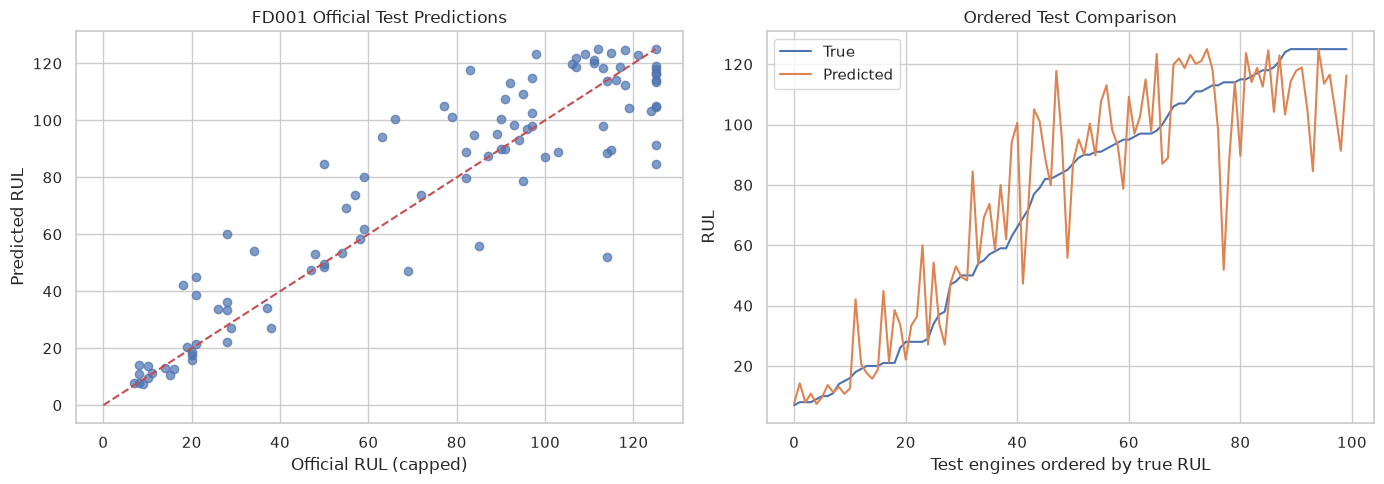

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    test_predictions_frame["true_RUL_capped"],
    test_predictions_frame["predicted_RUL"],
    alpha=0.7,
)
axes[0].plot([0, RUL_CAP], [0, RUL_CAP], "r--")
axes[0].set(
    xlabel="Official RUL (capped)",
    ylabel="Predicted RUL",
    title="FD001 Official Test Predictions",
)

ordered = test_predictions_frame.sort_values("true_RUL_capped").reset_index(drop=True)
axes[1].plot(ordered.index, ordered["true_RUL_capped"], label="True")
axes[1].plot(ordered.index, ordered["predicted_RUL"], label="Predicted")
axes[1].set(
    xlabel="Test engines ordered by true RUL",
    ylabel="RUL",
    title="Ordered Test Comparison",
)
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURE_DIR / "official_test_predictions.png", dpi=150)
plt.show()


## 12. Feature Importance


,feature,importance
0,sensor_4_mean_10,0.230864
1,sensor_4_mean_5,0.222517
2,sensor_15_mean_10,0.109952
3,sensor_11_mean_10,0.080466
4,sensor_11_mean_5,0.075288
5,sensor_15_mean_5,0.040070
6,sensor_2_mean_10,0.038498
7,sensor_9_mean_5,0.018994
8,cycle,0.011737
9,sensor_6_std_20,0.008812


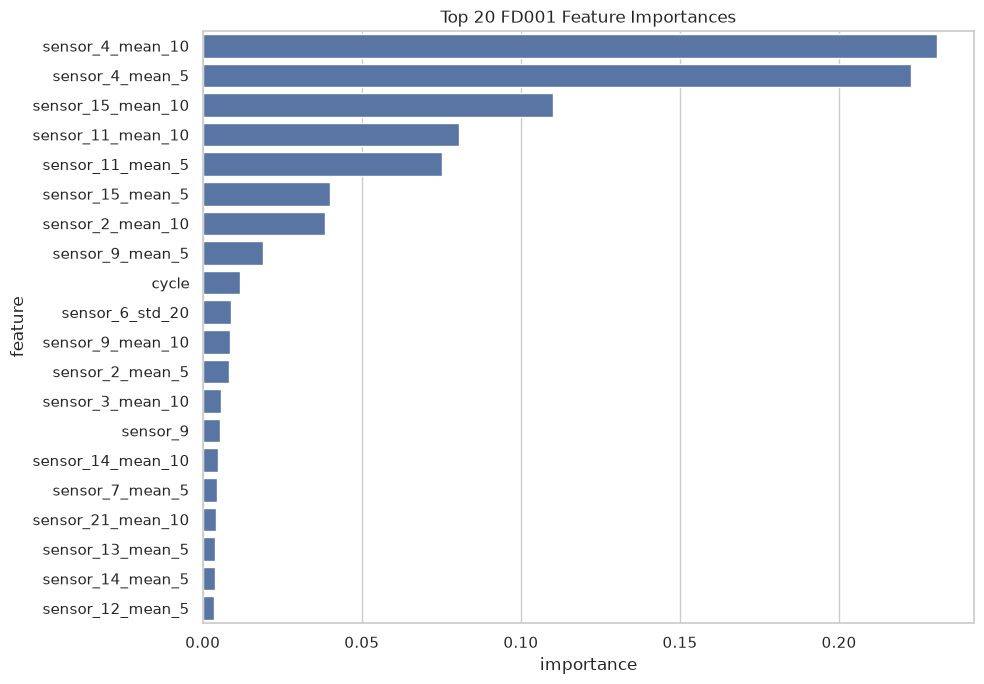

In [19]:
feature_importance = (
    pd.DataFrame(
        {
            "feature": FEATURE_COLUMNS,
            "importance": final_model.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.head(20))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=feature_importance.head(20),
    x="importance",
    y="feature",
)
plt.title("Top 20 FD001 Feature Importances")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "feature_importance.png", dpi=150)
plt.show()


## 13. Save Reproducible Artifacts

The metadata file is the inference contract: it records feature order, target
cap, rolling windows, dropped columns, parameters, and metrics.


In [20]:
model_path = ARTIFACT_DIR / "xgboost_fd001_rul.json"
metadata_path = ARTIFACT_DIR / "metadata.json"
predictions_path = ARTIFACT_DIR / "official_test_predictions.csv"
importance_path = ARTIFACT_DIR / "feature_importance.csv"
validation_path = ARTIFACT_DIR / "validation_comparison.csv"

final_model.save_model(model_path)
test_predictions_frame.to_csv(predictions_path, index=False)
feature_importance.to_csv(importance_path, index=False)
validation_comparison.to_csv(validation_path, index=False)

metadata = {
    "dataset": "NASA C-MAPSS FD001",
    "seed": SEED,
    "rul_cap": RUL_CAP,
    "rolling_windows": list(ROLLING_WINDOWS),
    "constant_columns": CONSTANT_COLUMNS,
    "base_features": BASE_FEATURES,
    "feature_columns": FEATURE_COLUMNS,
    "selected_parameters": best_params,
    "validation_metrics": best_validation_metrics,
    "test_metrics_capped": test_metrics_capped,
    "test_metrics_uncapped": test_metrics_uncapped,
    "train_engines": int(train_raw["unit"].nunique()),
    "test_engines": int(test_raw["unit"].nunique()),
}

metadata_path.write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

print("Saved model:", model_path.resolve())
print("Saved metadata:", metadata_path.resolve())
print("Saved predictions:", predictions_path.resolve())
print("Saved feature importance:", importance_path.resolve())


Saved model: /workspace/notebooks/artifacts/cmapss/fd001/xgboost_fd001_rul.json
Saved metadata: /workspace/notebooks/artifacts/cmapss/fd001/metadata.json
Saved predictions: /workspace/notebooks/artifacts/cmapss/fd001/official_test_predictions.csv
Saved feature importance: /workspace/notebooks/artifacts/cmapss/fd001/feature_importance.csv


## Completion Criteria

This notebook is complete when:

- the median and XGBoost validation metrics are displayed;
- XGBoost improves meaningfully over the median baseline;
- official test metrics and prediction plots are generated;
- `artifacts/cmapss/fd001/xgboost_fd001_rul.json` exists;
- metadata and official test predictions are saved.

If baseline validation is weak, enable hyperparameter tuning. If tuning gives no
meaningful improvement, keep the simpler baseline and inspect feature design
before moving to LSTM/GRU models.
